In [ ]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

In [4]:
def simulate_ARCH(x,n,alpha0,alpha1):
    if alpha0<=0 or alpha1<0:
        raise ValueError("Attention, ces conditions rendent la variance soit négative, soit elle divergera")
    z=rng.standard_normal(n)
    sigma_carre=alpha0+alpha1*(x**2)

    resultats=[0]*(n+1)
    resultats[0]=x

    vol=[0]*(n+1)
    vol[0]=sigma_carre

    for k in range(0,n):
        x=z[k]*np.sqrt(sigma_carre)
        sigma_carre=alpha0+alpha1*(x**2)
        resultats[k+1]=x
        vol[k+1]=sigma_carre
    return resultats,vol


In [25]:
alpha0=1
alpha1=0.5

In [130]:
x,vol=simulate_ARCH(0,2000000,alpha0,alpha1)


x_empirique=np.sum(x)/len(x)
termes=(x-x_empirique)**2
estimation=sum(termes)/len(termes)
print('L estimation de la variance inconditionelle est égal à',estimation)
print('La variance inconditionelle théorique est égal à',alpha0/(1-alpha1))

#Let's try to calculate Kurtosis
x=np.array(x)
x_empirique_4=np.sum(x**4)/len(x) #On sait que ça converge vers ce qu'on veut à l'aide du théorème érgodique
v_empirique_2=estimation**2 #Variance au carré (on a déjà calculé une estimation de la variance précédemment)

kurtosis_inc=x_empirique_4/v_empirique_2
print('L estimation du kurtosis coef inconditionnel est égal à',kurtosis_inc)
print('Le kurtosis coef inconditionnel théorique est égal à',3*((1-(alpha1**2))/(1-3*(alpha1**2))))

L estimation de la variance inconditionelle est égal à 1.9985530008160162
La variance inconditionelle théorique est égal à 2.0
L estimation du kurtosis coef inconditionnel est égal à 7.571884641146756
Le kurtosis coef inconditionnel théorique est égal à 9.0


In [148]:
def estimation(t, n, alpha0, alpha1):
    total_vol = [0] * n
    total_kurto = [0] * n

    for k in range(n):
        x, vol = simulate_ARCH(0, t, alpha0, alpha1)

        x = np.array(x)

        # Moyenne empirique
        x_empirique = np.mean(x)

        # Variance empirique
        termes = (x - x_empirique) ** 2
        estimation = np.mean(termes)

        total_vol[k] = estimation

        # Kurtosis
        x_empirique_4 = np.mean(x ** 4)
        v_empirique_2 = estimation ** 2

        kurtosis_inc = x_empirique_4 / v_empirique_2

        total_kurto[k] = kurtosis_inc

    return total_vol, total_kurto

Text(0, 0.5, 'Kurto coef')

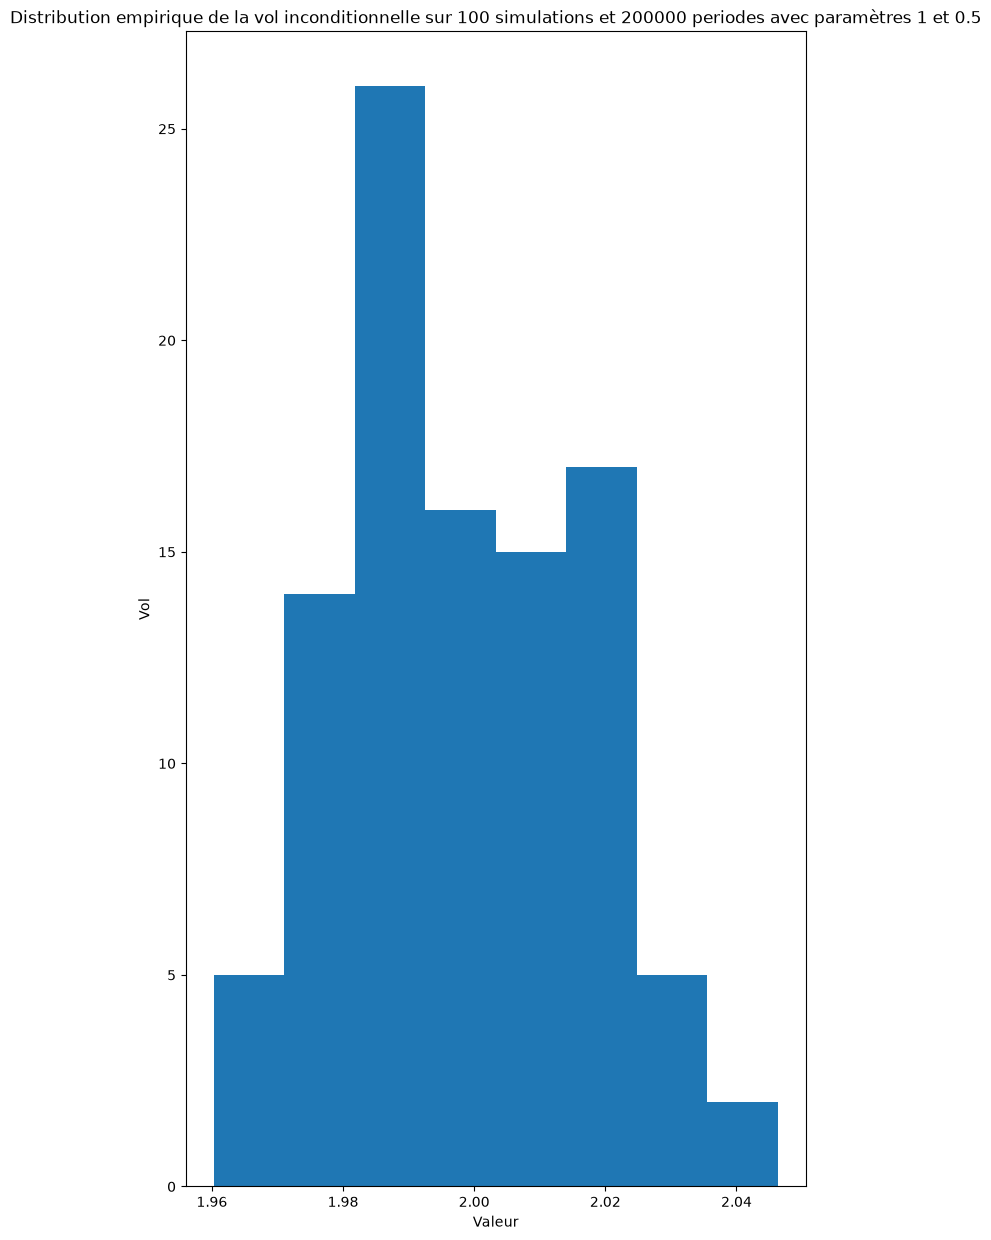

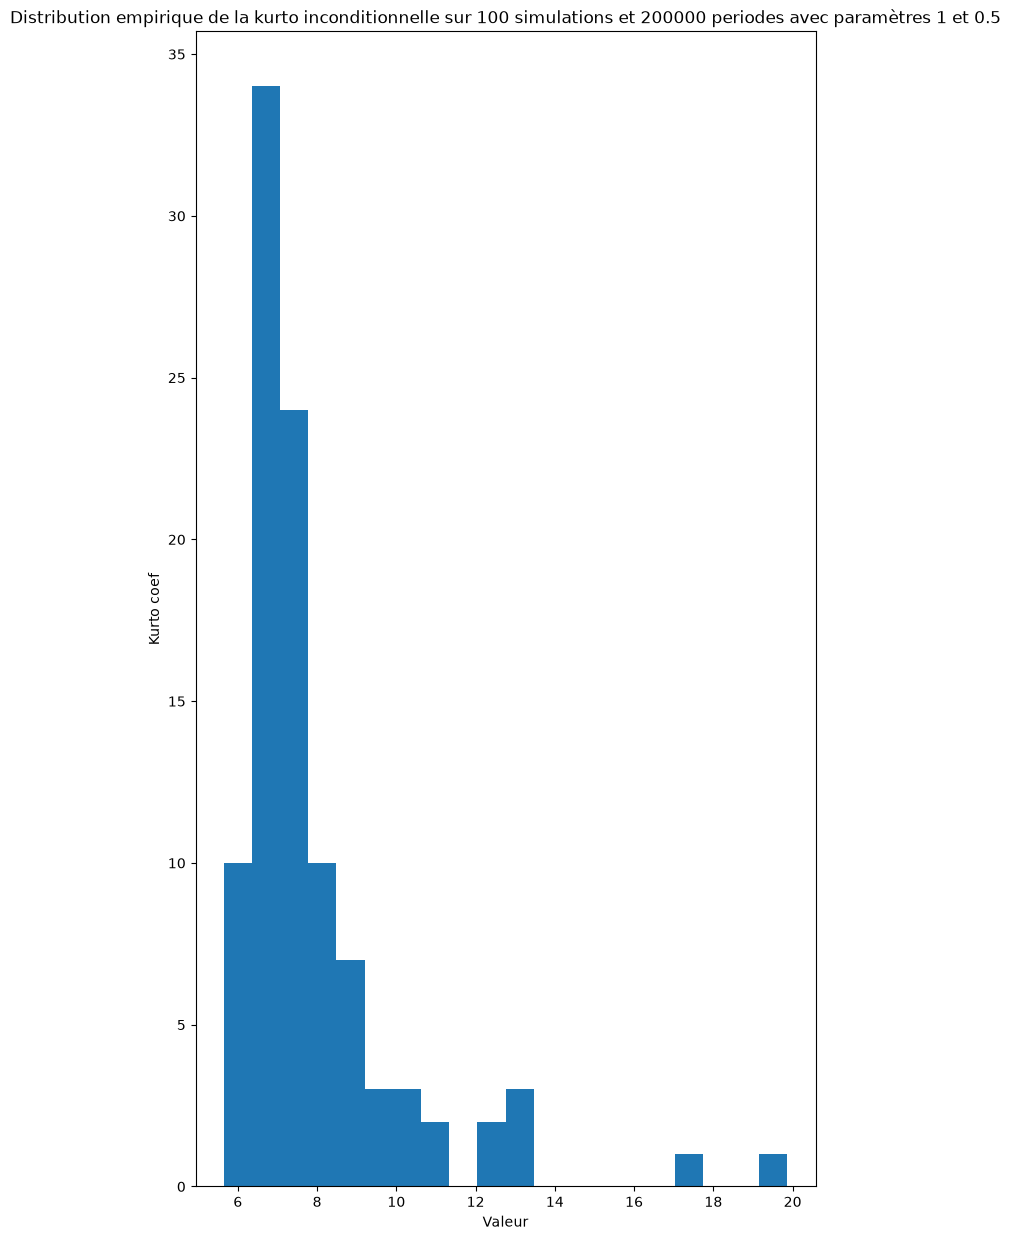

In [ ]:
t=200000
n=100
alpha0=1
alpha1=0.5

total_vol,total_kurto=estimation(t,n,alpha0,alpha1)

vol_theorique=
kurto_theorique=3*((1-(alpha1**2))/(1-3*(alpha1**2)))


plt.figure(figsize=(8,15))
plt.hist(total_vol,bins='auto')
plt.title(f'Distribution empirique de la vol inconditionnelle sur {n} simulations et {t} periodes avec paramètres {alpha0} et {alpha1}')
plt.xlabel('Valeur')
plt.ylabel('Vol')

plt.figure(figsize=(8,15))
plt.hist(total_kurto,bins='auto')
plt.axvline(3*((1-(alpha1**2))/(1-3*(alpha1**2))), color='red', linestyle='--')
plt.title(f'Distribution empirique de la kurto inconditionnelle sur {n} simulations et {t} periodes avec paramètres {alpha0} et {alpha1}')
plt.xlabel('Valeur')
plt.ylabel('Kurto coef')

In [6]:
print(f'Les premières réalisations de X sont {x[0]:.2f},{x[1]:.2f},{x[2]:.2f},{x[3]:.2f},{x[4]:.2f}')
print(f'Les premières réalisations de sigma_carre sont {vol[0]:.2f},{vol[1]:.2f},{vol[2]:.2f},{vol[3]:.2f},{vol[4]:.2f}')

Les premières réalisations de X sont 0.00,-1.55,0.95,2.04,-1.45
Les premières réalisations de sigma_carre sont 1.00,2.20,1.45,3.08,2.06


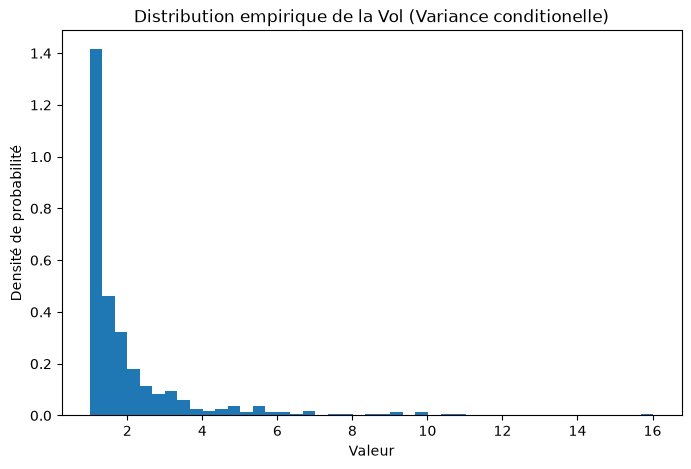

In [ ]:
#Est-ce que c'est vraiment utile ?
plt.figure(figsize=(8, 5))
plt.hist(vol,bins='auto',density=True)
plt.title('Distribution empirique de la Vol (Variance conditionelle)')
plt.xlabel('Valeur')
plt.ylabel('Densité de probabilité')
plt.show()

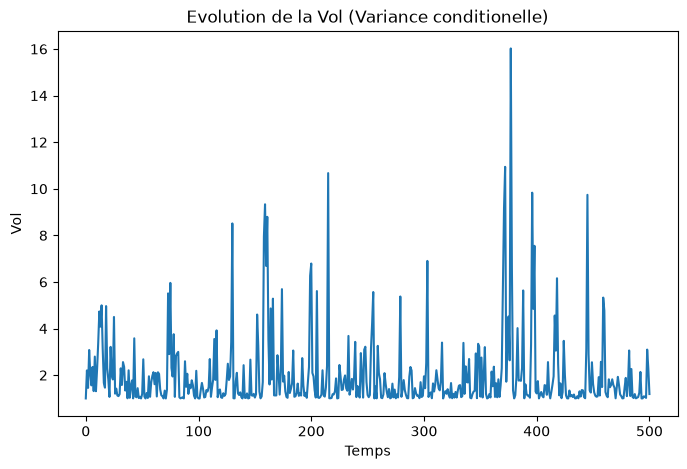

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(vol)
plt.title('Evolution de la Vol (Variance conditionelle)')
plt.xlabel('Temps')
plt.ylabel('Vol')
plt.show()

In [ ]:
from numpy.polynomial import Polynomial
from scipy.linalg import toeplitz
from statsmodels.tsa.arima_process import ArmaProcess

#Let's try to simulate a AR process (with random coefficients) and a white noise that follows normal law (0,sigma)
#Let's begin by considering without a constant
def AR(p,sigma,n):
    racines=1/rng.uniform(-1,1,p) #We first begin to create random roots

    P_unitaire = Polynomial.fromroots(racines) #We create our polynome using our roots (unitary polynome)
    P_final=P_unitaire

    coefficients = P_final.coef #Ce ne sont pas les phi attention (mais - phi)
    ar = P_final.coef / P_final.coef[0] #On force le polynome à être unitaire

    ma = np.array([1]) #On crée un MA constant (juste pour mettre l'argument dans ARMA Process)

    processus = ArmaProcess(ar,ma)

    gamma = processus.acovf(nobs=p) * (sigma) #Notre vecteur d'auto covariance
    matrice_covariance = toeplitz(gamma[:p]) # Matrice de covariance à l'aide de Toeplitz
    
    mean = np.zeros(p) 

    init=rng.multivariate_normal(mean,matrice_covariance)
    evo=[0]*n

    total = np.concatenate([init, evo])

    phis=-ar[1:] #On enlève la constante
    phis=phis[::-1] #On met dans l'ordre inverse


    for k in range(p,len(total)):
        bruit=rng.normal(0,sigma**2)
        x0=phis@total[k-p:k]+bruit
        total[k]=x0
    
    plt.figure(figsize=(8, 5))
    plt.plot(total)
    plt.title(f'AR({p}) sur {n+p} périodes et un écart-type {sigma}')
    plt.xlabel('Temps')
    plt.ylabel('Xt')
    plt.show()
    print('racines inverses : ',racines) 

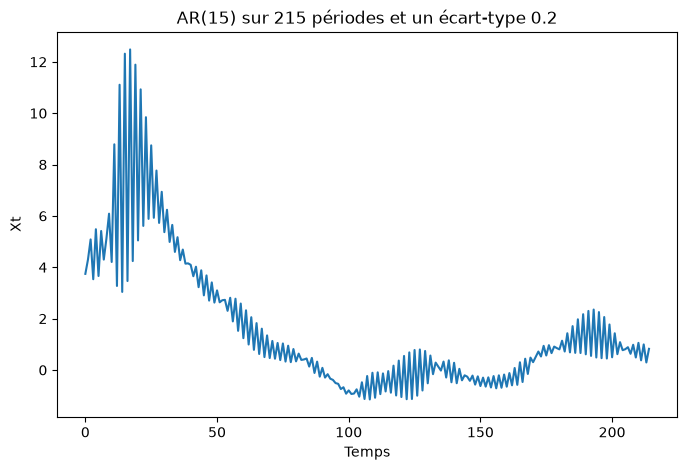

racines inverses :  [-1.37260605  1.03416139  1.73792293 10.2351938  -5.07674961 -1.81036316
  1.43050775  1.45700348 -1.56689328  5.83766158 -1.34479854 -1.95537829
 -5.35895088  1.22951164 -1.336857  ]


In [84]:
AR(15,0.2,200)